### Classificação de textos do Twitter com spaCy

### Importação e instalação das bibliotecas

In [1]:
!pip install spacy

In [2]:
import spacy
spacy.__version__

'3.8.14'

In [3]:
!python -m spacy download pt_core_news_sm

     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     ------------- -------------------------- 4.5/13.0 MB 32.0 MB/s eta 0:00:01
     --------------------------------------- 13.0/13.0 MB 42.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [7]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.5 MB/s eta 0:00:04
     ---- ----------------------------------- 1.3/12.8 MB 3.8 MB/s eta 0:00:04
     ------- -------------------------------- 2.4/12.8 MB 4.0 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.1 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 4.2 MB/s eta 0:00:03
     ---------------- ----------------------- 5.2/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 4.4 MB/s eta 0:00:02
     ----------------------- ---------------- 7.6/12.8 MB 4.6 MB/s eta 0:00:02
     --------------------------- ------------ 8.7/12.8 MB 4.7 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 4.9 MB/s eta 0:00:01
     ------------------------------------ --- 11.5/12.8 MB 5.0 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 M

In [8]:
import pandas as pd
import string
import spacy
import en_core_web_sm
import random
import seaborn as sns
import numpy as np
import re

### Carregamento das bases de dados

- Link Kaggle: https://www.kaggle.com/augustop/portuguese-tweets-for-sentiment-analysis#TweetsNeutralHash.csv

### Base de treinamento

- Negative label:0
- Positive label:1

In [13]:
base_treinamento = pd.read_csv("train50.csv", delimiter=";")

In [14]:
base_treinamento.shape

(50000, 5)

In [15]:
base_treinamento.head()

,id,tweet_text,tweet_date,sentiment,query_used
0,1050785521201541121,@Laranjito76 A pessoa certa para isso seria o ...,Fri Oct 12 16:29:25 +0000 2018,1,:)
1,1050785431955140608,"@behin_d_curtain Para mim, é precisamente o co...",Fri Oct 12 16:29:04 +0000 2018,1,:)
2,1050785401248645120,Vou fazer um video hoje... estou pensando em f...,Fri Oct 12 16:28:56 +0000 2018,1,:)
3,1050785370982547461,"aaaaaaaa amei tanto essas polaroids, nem sei e...",Fri Oct 12 16:28:49 +0000 2018,1,:)
4,1050785368902131713,Valoriza o coração do menininho que vc tem. El...,Fri Oct 12 16:28:49 +0000 2018,1,:)


<Axes: ylabel='count'>

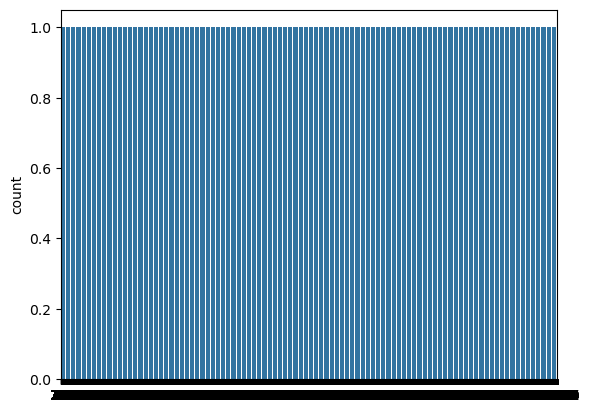

In [16]:
sns.countplot(base_treinamento['sentiment'], label="Countagem")

In [17]:
base_treinamento.drop(['id', 'tweet_date', 'query_used'], axis=1, inplace=True)